# 实践实验：线性回归

欢迎参加你的第一个实践实验！在本实验中，你将实现单变量线性回归，用于预测连锁餐厅的利润。


# 大纲
- [ 1 - 软件包 ](#1)
- [ 2 - 单变量线性回归 ](#2)
  - [ 2.1 问题陈述](#2.1)
  - [ 2.2 数据集](#2.2)
  - [ 2.3 线性回归回顾](#2.3)
  - [ 2.4 计算代价](#2.4)
    - [ 练习 1](#ex01)
  - [ 2.5 梯度下降 ](#2.5)
    - [ 练习 2](#ex02)
  - [ 2.6 使用批量梯度下降学习参数 ](#2.6)

<a name="1"></a>
## 1 - 软件包

首先，运行下面的单元格，导入完成本作业所需的全部软件包。
- [NumPy](www.numpy.org) 是在 Python 中处理矩阵的基础软件包。
- [matplotlib](http://matplotlib.org) 是 Python 中著名的绘图库。
- ``utils.py`` 包含本作业的辅助函数。你无需修改该文件中的代码。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

## 2 - 问题陈述

假设你是一家连锁餐厅的首席执行官，正在考虑到不同城市开设新门店。
- 你希望将业务拓展到可能为餐厅带来更高利润的城市。
- 该连锁餐厅已在多个城市开设门店，你拥有这些城市的人口和利润数据。
- 你还拥有新餐厅候选城市的数据。
    - 对于这些城市，你掌握了城市人口数据。
    
你能否利用这些数据，帮助确定哪些城市可能为企业带来更高利润？

## 3 - 数据集

首先，你将加载此任务的数据集。
- 下面所示的 `load_data()` 函数会将数据加载到变量 `x_train` 和 `y_train` 中
  - `x_train` 是一个城市的人口
  - `y_train` 是该城市中一家餐厅的利润。利润为负值表示亏损。
  - `X_train` 和 `y_train` 都是 NumPy 数组。

In [2]:
# load the dataset
x_train, y_train = load_data()

#### 查看变量
开始任何任务之前，进一步熟悉数据集都很有帮助。  
- 一个很好的起点是直接打印每个变量，看看其中包含什么。

下面的代码会打印变量 `x_train` 及该变量的类型。

In [4]:
# print x_train
print("Type of x_train:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5]) 

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]


`x_train` 是一个 NumPy 数组，其中包含全部大于零的小数值。
- 这些值表示城市人口数除以 10,000；
- 例如，6.1101 表示该城市人口为 61,101。
  
现在，让我们打印 `y_train`。

In [5]:
# print y_train
print("Type of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5])  

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


类似地，`y_train` 是一个包含小数值的 NumPy 数组，其中有些为负，有些为正。
- 这些值表示你的餐厅在各城市的平均月利润，单位为 \\$10,000。
  - 例如，17.592 表示该城市的平均月利润为 \\$175,920。
  - -2.6807 表示该城市的平均月亏损为 -\\$26,807。

#### 检查变量的维度

另一种熟悉数据的有效方法是查看其维度。

请打印 `x_train` 和 `y_train` 的形状，看看数据集中有多少个训练样本。

In [7]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


城市人口数组有 97 个数据点，月平均利润数组也有 97 个数据点。它们都是 NumPy 一维数组。

#### 可视化数据

通过可视化来理解数据通常很有帮助。
- 对于此数据集，由于只有两个可绘制属性（利润和人口），可以使用散点图进行可视化。
- 在现实中遇到的许多其他问题会有两个以上的属性（例如人口、家庭平均收入、月利润、月销售额）。当属性超过两个时，仍可使用散点图观察每对属性之间的关系。

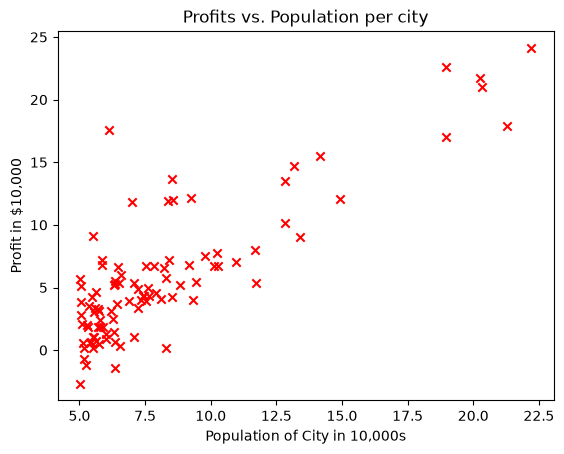

In [8]:
# Create a scatter plot of the data. To change the markers to red "x",
# we used the 'marker' and 'c' parameters
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

你的目标是构建一个线性回归模型来拟合这些数据。
- 借助该模型，你可以输入一个新城市的人口，并让模型估算你的餐厅在该城市的潜在月利润。

<a name="4"></a>
## 4 - 线性回归复习

在本练习实验中，你将把线性回归参数 $(w,b)$ 拟合到数据集。
- 线性回归的模型函数，是一个从 `x`（城市人口）映射到 `y`（你的餐厅在该城市的月利润）的函数，表示为
    $$f_{w,b}(x) = wx + b$$
    

- 要训练线性回归模型，需要找到最适合数据集的参数 $(w,b)$。

    - 要比较一种 $(w,b)$ 选择相对于另一种选择是更好还是更差，可以使用代价函数 $J(w,b)$ 对其进行评估
      - $J$ 是 $(w,b)$ 的函数。也就是说，代价 $J(w,b)$ 的值取决于 $(w,b)$ 的值。
  
    - 最适合数据的 $(w,b)$ 选择，是使代价 $J(w,b)$ 最小的选择。


- 要找到使代价 $J(w,b)$ 尽可能小的值 $(w,b)$，可以使用一种称为**梯度下降**的方法。
  - 梯度下降每执行一步，参数 $(w,b)$ 就会更接近能够实现最低代价 $J(w,b)$ 的最优值。
  

- 训练后的线性回归模型可以接收输入特征 $x$（城市人口），并输出预测值 $f_{w,b}(x)$（该城市中某餐厅的预测月利润）。

<a name="5"></a>
## 5——计算代价

梯度下降需要反复调整参数 $(w,b)$ 的值，使代价 $J(w,b)$ 逐渐减小。
- 在梯度下降的每一步中，随着 $(w,b)$ 的更新，计算代价 $J(w,b)$ 有助于监控进度。
- 在本节中，您将实现一个计算 $J(w,b)$ 的函数，以便检查梯度下降实现的进展。

#### 代价函数
您可能还记得课程中的内容，对于单变量，线性回归 $J(w,b)$ 的代价函数定义为：

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$ 

- 可以把 $f_{w,b}(x^{(i)})$ 看作模型对餐厅利润的预测，而 $y^{(i)}$ 是数据中记录的实际利润。
- $m$ 是数据集中的训练样本数量。

#### 模型预测

- 对于单变量线性回归，模型对样本 $x^{(i)}$ 的预测 $f_{w,b}$ 表示为：

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b$$

这是一条直线的公式，其中 $b$ 为截距，$w$ 为斜率。

#### 实现

请完成下面的 `compute_cost()` 函数，以计算代价 $J(w,b)$。

<a name="ex01"></a>
### 练习 1

补全下面的 `compute_cost` 以完成以下任务：

* 遍历训练样本，并对每个样本计算：
    * 模型对该样本的预测值
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
    * 该样本的代价 $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$
    

* 返回所有样本的总代价
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$
  * 其中，$m$ 是训练样本数，$\sum$ 是求和运算符

如果遇到困难，可以查看下方单元格之后给出的提示，以帮助你完成实现。

In [11]:
# UNQ_C1
# GRADED FUNCTION: compute_cost

def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
        x (ndarray): Shape (m,) Input to the model (Population of cities) 
        y (ndarray): Shape (m,) Label (Actual profits for the cities)
        w, b (scalar): Parameters of the model
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # number of training examples
    m = x.shape[0] 
    
    # You need to return this variable correctly
    total_cost = 0
    
    ### START CODE HERE ###  
    const_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        const_sum = const_sum + cost
    ### END CODE HERE ### 
    total_cost = (1 / (2 * m)) * const_sum

    return total_cost

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
    
   * 在代码中，可以按如下方式表示求和运算符（例如 $h = \sum\limits_{i = 0}^{m-1} 2i$）：
     ```python 
    h = 0
    for i in range(m):
        h = h + 2*i
    ```
  
   * 在本例中，您可以使用 for 循环遍历 `x` 中的所有样本，并将每次迭代得到的 `cost` 加到循环外初始化的变量（`cost_sum`）中。

   * 然后，可以返回 `total_cost`，即 `cost_sum` 除以 `2m`。
     
    <details>
          <summary><font size="2" color="darkblue"><b> 点击查看更多提示</b></font></summary>
        
    * 下面展示了该函数整体实现的组织方式。
    ```python 
    def compute_cost(x, y, w, b):
        # number of training examples
        m = x.shape[0] 
    
        # You need to return this variable correctly
        total_cost = 0
    
        ### START CODE HERE ###  
        # Variable to keep track of sum of cost from each example
        cost_sum = 0
    
        # Loop over training examples
        for i in range(m):
            # Your code here to get the prediction f_wb for the ith example
            f_wb = 
            # Your code here to get the cost associated with the ith example
            cost = 
        
            # Add to sum of cost for each example
            cost_sum = cost_sum + cost 

        # Get the total cost as the sum divided by (2*m)
        total_cost = (1 / (2 * m)) * cost_sum
        ### END CODE HERE ### 

        return total_cost
    ```
    
    如果您仍然没有思路，可以查看下面的提示，了解如何计算 `f_wb` 和 `cost`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
           &emsp; &emsp; 对于标量 $a$、$b$ 和 $c$（<code>x[i]</code>、<code>w</code> 和 <code>b</code> 都是标量），可以在代码中将公式 $h = ab + c$ 写为 <code>h = a * b + c</code>。
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f 的更多提示</b></font></summary>
               &emsp; &emsp; 您可以按如下方式计算 f_wb：<code>f_wb = w * x[i] + b </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>计算代价的提示</b></font></summary>
          &emsp; &emsp; 可以用 z**2 计算变量 z 的平方。
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算代价的更多提示</b></font></summary>
              &emsp; &emsp; 您可以按如下方式计算代价：<code>cost = (f_wb - y[i]) ** 2</code>
          </details>
    </details>
        
    </details>

</details>

    

可以通过运行以下测试代码检查实现是否正确：

In [12]:
# Compute cost with some initial values for paramaters w, b
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w (zeros): {cost:.3f}')

# Public tests
from public_tests import *
compute_cost_test(compute_cost)

<class 'numpy.float64'>
Cost at initial w (zeros): 75.203
All tests passed!


**预期输出**：
<table>
  <tr>
    <td> <b>初始 w（全零）处的代价：<b> 75.203 </td> 
  </tr>
</table>

<a name="6"></a>
## 6——梯度下降

在本节中，您将实现线性回归参数 $w, b$ 的梯度。

如课程视频所述，梯度下降算法为：

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & \phantom {0000} b := b -  \alpha \frac{\partial J(w,b)}{\partial b} \newline       \; & \phantom {0000} w := w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{1}  \; & 
\newline & \rbrace\end{align*}$$

其中，参数 $w, b$ 会同时更新，并且
$$
\frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{2}
$$
$$
\frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} \tag{3}
$$
* m 是数据集中的训练样本数

    
* $f_{w,b}(x^{(i)})$ 是模型的预测值，而 $y^{(i)}$ 是目标值


你将实现一个名为 `compute_gradient` 的函数，用于计算 $\frac{\partial J(w)}{\partial w}$ 和 $\frac{\partial J(w)}{\partial b}$

<a name="ex02"></a>
### 练习 2

请完成 `compute_gradient` 函数：

* 遍历训练样本，并针对每个样本计算：
    * 模型对该样本的预测
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
   
    * 该样本对应参数 $w, b$ 的梯度
        $$
        \frac{\partial J(w,b)}{\partial b}^{(i)}  =  (f_{w,b}(x^{(i)}) - y^{(i)}) 
        $$
        $$
        \frac{\partial J(w,b)}{\partial w}^{(i)}  =  (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} 
        $$
    

* 返回所有样本带来的总梯度更新
    $$
    \frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial b}^{(i)}
    $$
    
    $$
    \frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial w}^{(i)} 
    $$
  * 其中，$m$ 是训练样本数量，$\sum$ 是求和运算符

如果遇到困难，可以查看下面单元格之后给出的提示来帮助完成实现。

In [13]:
# UNQ_C2
# GRADED FUNCTION: compute_gradient
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]
    
    # You need to return the following variables correctly
    dj_dw = 0
    dj_db = 0
    
    ### START CODE HERE ### 
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        dj_dw += dj_dw_i
    ### END CODE HERE ### 
    dj_dw = dj_dw / m
    dj_db = dj_db / m   
    return dj_dw, dj_db

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
       
    * 可以在代码中按如下方式表示求和运算符，例如 $h = \sum\limits_{i = 0}^{m-1} 2i$：
     ```python 
    h = 0
    for i in range(m):
        h = h + 2*i
    ```
    
    * 在本例中，可以使用 for 循环遍历 `x` 中的所有样本；对于每个样本，将该样本的梯度持续累加到在循环外初始化的变量 `dj_dw` 和 `dj_db` 中。

   * 然后，返回 `dj_dw` 和 `dj_db`，并将两者都除以 `m`。    
    <details>
          <summary><font size="2" color="darkblue"><b> 点击查看更多提示</b></font></summary>
        
    * 此函数的整体实现可以采用以下结构
    ```python 
    def compute_gradient(x, y, w, b): 
        """
        Computes the gradient for linear regression 
        Args:
          x (ndarray): Shape (m,) Input to the model (Population of cities) 
          y (ndarray): Shape (m,) Label (Actual profits for the cities)
          w, b (scalar): Parameters of the model  
        Returns
          dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
          dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
         """
    
        # Number of training examples
        m = x.shape[0]
    
        # You need to return the following variables correctly
        dj_dw = 0
        dj_db = 0
    
        ### START CODE HERE ### 
        # Loop over examples
        for i in range(m):  
            # Your code here to get prediction f_wb for the ith example
            f_wb = 
            
            # Your code here to get the gradient for w from the ith example 
            dj_dw_i = 
        
            # Your code here to get the gradient for b from the ith example 
            dj_db_i = 
     
            # Update dj_db : In Python, a += 1  is the same as a = a + 1
            dj_db += dj_db_i
        
            # Update dj_dw
            dj_dw += dj_dw_i
    
        # Divide both dj_dw and dj_db by m
        dj_dw = dj_dw / m
        dj_db = dj_db / m
        ### END CODE HERE ### 
        
        return dj_dw, dj_db
    ```
    
    如果仍然遇到困难，可以查看下面的提示，了解如何计算 `f_wb` 和 `cost`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
           &emsp; &emsp; 你在上一个练习中已经完成过！对于标量 $a$、$b$ 和 $c$（<code>x[i]</code>、<code>w</code> 和 <code>b</code> 都是标量），可以在代码中将公式 $h = ab + c$ 写为 <code>h = a * b + c</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f 的更多提示</b></font></summary>
               &emsp; &emsp; 可以按如下方式计算 f_wb：<code>f_wb = w * x[i] + b </code>
           </details>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算 dj_dw_i 的提示</b></font></summary>
           &emsp; &emsp; 对于标量 $a$、$b$ 和 $c$（<code>f_wb</code>、<code>y[i]</code> 和 <code>x[i]</code> 都是标量），可以在代码中将公式 $h = (a - b)c$ 写为 <code>h = (a-b)*c</code>
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f 的更多提示</b></font></summary>
               &emsp; &emsp; 可以按如下方式计算 dj_dw_i：<code>dj_dw_i = (f_wb - y[i]) * x[i] </code>
           </details>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算 dj_db_i 的提示</b></font></summary>
             &emsp; &emsp; 可以按如下方式计算 dj_db_i：<code> dj_db_i = f_wb - y[i] </code>
    </details>
        
    </details>

</details>

    

运行下面的单元格，使用参数 $w$、$b$ 的两种不同初始化来检查 `compute_gradient` 函数的实现。

In [14]:
# Compute and display gradient with w initialized to zeroes
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

compute_gradient_test(compute_gradient)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


现在，让我们在数据集上运行上面实现的梯度下降算法。

**预期输出**：
<table>
  <tr>
    <td> <b>初始位置处的梯度，b（全零）<b></td>
    <td> -65.32884975 -5.83913505154639</td> 
  </tr>
</table>

In [15]:
# Compute and display cost and gradient with non-zero w
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: -47.41610118114435 -4.007175051546391


**预期输出**：
<table>
  <tr>
    <td> <b>测试 w 处的梯度<b></td>
    <td> -47.41610118 -4.007175051546391</td> 
  </tr>
</table>

<a name="2.6"></a>
### 2.6 使用批量梯度下降学习参数

现在，你将使用批量梯度下降找到线性回归模型的最优参数。回顾一下，“批量”是指在一次迭代中处理所有样本。
- 这一部分无需实现任何内容，只需运行下面的单元格。

- 验证梯度下降是否正确工作的一种好方法，是观察 $J(w,b)$ 的值，并检查它是否随每一步不断减小。

- 假设你正确实现了梯度并计算了代价，同时为学习率 alpha 选择了合适的值，那么 $J(w,b)$ 绝不应增大，并且在算法结束时应收敛到一个稳定值。

In [16]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      w_in, b_in : (scalar) Initial values of parameters of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(x)
    
    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b )  

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history #return w and J,w history for graphing

现在，让我们运行上面的梯度下降算法，学习数据集的参数。

In [17]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     6.74   
Iteration  150: Cost     5.31   
Iteration  300: Cost     4.96   
Iteration  450: Cost     4.76   
Iteration  600: Cost     4.64   
Iteration  750: Cost     4.57   
Iteration  900: Cost     4.53   
Iteration 1050: Cost     4.51   
Iteration 1200: Cost     4.50   
Iteration 1350: Cost     4.49   
w,b found by gradient descent: 1.166362350335582 -3.63029143940436


**预期输出**：
<table>
  <tr>
    <td> <b>梯度下降求得的 w、b<b></td>
    <td> 1.16636235 -3.63029143940436</td> 
  </tr>
</table>

现在，我们将使用梯度下降得到的最终参数绘制线性拟合。

回顾一下，我们可以获得单个样本 $f(x^{(i)})= wx^{(i)}+b$ 的预测。

要计算整个数据集上的预测，可以遍历所有训练样本，并为每个样本计算预测。下面的代码块展示了这一过程。

In [18]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

现在，我们将绘制预测值以查看线性拟合效果。

Text(0.5, 0, 'Population of City in 10,000s')

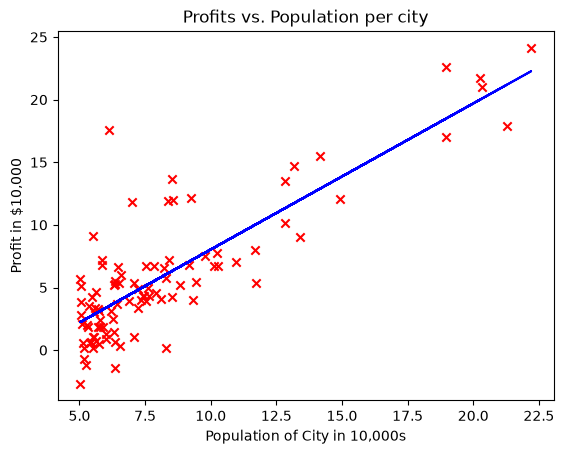

In [19]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')

$w,b$ 的最终值还可用于预测利润。让我们预测人口为 35,000 和 70,000 的地区会获得多少利润。

- 模型以一个城市的人口数作为输入，单位为万人。

- 因此，35,000 人可以转换为模型输入 `np.array([3.5])`

- 同样，70,000 人可以转换为模型输入 `np.array([7.])`

In [20]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


**预期输出**：
<table>
  <tr>
    <td> <b> 对于人口 = 35,000，我们预测利润为<b></td>
    <td> $4519.77 </td> 
  </tr>
  
  <tr>
    <td> <b> 对于人口 = 70,000，我们预测利润为<b></td>
    <td> $45342.45 </td> 
  </tr>
</table>